=== Introducción al Análisis Exploratorio de Datos para Zuber. ===

Como analista de datos en Zuber, una nueva empresa de viajes compartidos que busca posicionarse estratégicamente en la ciudad de Chicago, resulta fundamental comprender a profundidad el comportamiento de los usuarios y las dinámicas que influyen en la demanda de viajes. Para ello, se realiza un Análisis Exploratorio de Datos (EDA) cuyo propósito es identificar patrones, tendencias y relaciones clave dentro de la información disponible.

Este análisis permite responder preguntas esenciales para el crecimiento de la empresa: ¿qué preferencias muestran los pasajeros?, ¿cómo varían los viajes según la hora, el clima o la ubicación?, ¿qué factores externos influyen en la actividad del servicio? Al examinar estas dimensiones, Zuber podrá optimizar su oferta, ajustar su estrategia operativa y anticipar necesidades del mercado local.

El EDA se convierte así en un paso crítico para transformar datos sin procesar en conocimiento accionable, proporcionando una base sólida para futuras decisiones de negocio, modelos predictivos y estrategias de expansión.

=== PARTE 4. Análisis exploratorio de datos (EDA). === 

In [1]:
#Importacion de libreria para el EDA del proyecto:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Para la prueba de hipótesis:
from scipy import stats
from scipy.stats import shapiro, mannwhitneyu
import numpy as np

In [2]:
#Carga de datasets para el EDA.
company_trips = pd.read_csv('/datasets/project_sql_result_01.csv')
avg_trips_location = pd.read_csv('/datasets/project_sql_result_04.csv')
weather_records = pd.read_csv('/datasets/project_sql_result_07.csv')

In [3]:
#imprimiendo la informacion de cada dataframe:
print('=== INFORMACION: Company_trips ===')
company_trips.info()
print(company_trips.describe())
print()
print('=== INFORMACION: trips_location ===')
avg_trips_location.info()
print(avg_trips_location.describe())
print()
print('=== INFORMACION: weather_records ===')
weather_records.info()
print(weather_records.describe())

=== INFORMACION: Company_trips ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
       trips_amount
count     64.000000
mean    2145.484375
std     3812.310186
min        2.000000
25%       20.750000
50%      178.500000
75%     2106.500000
max    19558.000000

=== INFORMACION: trips_location ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
       average_trips
count      94.000000
mean      599.953728
std

El conjunto de datos inicial está compuesto por tres fuentes principales —Company_trips, trips_location y weather_records— que permiten abordar el análisis desde tres ángulos complementarios: oferta de viajes por empresa, distribución espacial de los destinos y condiciones externas que pueden influir en la duración de los trayectos. A continuación se presenta un análisis detallado de cada uno.

=== Company_trips (64 registros, 2 columnas) ===

Este dataframe contiene información sobre la cantidad de viajes realizados por diferentes compañías de transporte. Este dataset será clave para entender el panorama competitivo en Chicago y posicionar a Zuber frente a sus rivales.

=== trips_location (94 registros, 2 columnas) ===

Este dataframe describe los destinos de los viajes mediante el nombre del punto de descenso y el promedio de viajes asociados a cada ubicación. Este dataset será fundamental para construir mapas de calor, rankings de destinos y patrones de movilidad urbana.

=== weather_records (1068 registros, 3 columnas) ===

Este dataset será clave para modelar la relación entre factores externos y desempeño del servicio.

=== Conclusión ===

Los tres dataframes ofrecen una base sólida para iniciar el EDA. Cada uno aporta una dimensión distinta del sistema de movilidad:

Competencia (Company_trips)

Demanda geográfica (trips_location)

Factores externos y desempeño operativo (weather_records)

La combinación de estas fuentes permitirá construir una visión integral del mercado de viajes compartidos en Chicago y generar recomendaciones estratégicas para el lanzamiento de Zuber.

In [4]:
# Visualizacion de los dataframes.

print('==== DATA FRAME: COMPANY_TRIPS ===')
print(company_trips.head(20))
print()
print('==== DATA FRAME: TRIPS_LOCATION ===')
print(avg_trips_location.head(20))
print()
print('==== DATA FRAME: WEATHER_RECORDS ===')
print(weather_records.head(20))

==== DATA FRAME: COMPANY_TRIPS ===
                               company_name  trips_amount
0                                 Flash Cab         19558
1                 Taxi Affiliation Services         11422
2                         Medallion Leasing         10367
3                                Yellow Cab          9888
4           Taxi Affiliation Service Yellow          9299
5                 Chicago Carriage Cab Corp          9181
6                              City Service          8448
7                                  Sun Taxi          7701
8                 Star North Management LLC          7455
9         Blue Ribbon Taxi Association Inc.          5953
10                  Choice Taxi Association          5015
11                               Globe Taxi          4383
12                Dispatch Taxi Affiliation          3355
13                Nova Taxi Affiliation Llc          3175
14  Patriot Taxi Dba Peace Taxi Association          2235
15                 Checker Taxi Affil

=== Conclusión general del análisis de los primeros 20 registros. ===

Company_trips: un mercado dominado por pocos actores fuertes

Las primeras observaciones muestran que el volumen de viajes está altamente concentrado en un grupo reducido de compañías. Flash Cab, Taxi Affiliation Services y Medallion Leasing destacan como líderes con cifras significativamente superiores al resto. Esta estructura sugiere un mercado donde unas cuantas empresas tienen una presencia dominante, mientras que otras operan con volúmenes más modestos.
Este patrón abre la puerta a explorar cómo se distribuye la demanda entre competidores y qué factores podrían explicar estas diferencias.

Trips_location: zonas de alta demanda claramente definidas

Las ubicaciones iniciales revelan una jerarquía espacial muy marcada. Loop, River North y Streeterville encabezan la lista como los destinos más frecuentados, lo que coincide con áreas de intensa actividad laboral, turística y comercial en Chicago.
A medida que se avanza en la lista, aparecen barrios residenciales y zonas periféricas con menor promedio de viajes, lo que permite anticipar patrones de movilidad diferenciados entre el centro y los alrededores.
Este comportamiento espacial será clave para comprender cómo se distribuye la demanda y qué zonas podrían representar oportunidades estratégicas para Zuber.

Weather_records: Duraciones de viaje influenciadas por condiciones y horarios

Los primeros registros muestran duraciones de viaje que oscilan principalmente entre 20 y 45 minutos, con variaciones asociadas a diferentes horas del día y condiciones climáticas catalogadas como “Good” o “Bad”.
Aunque la mayoría de los viajes se registran bajo clima favorable, ya se observa que los trayectos en condiciones “Bad” tienden a ser más largos, lo que sugiere una relación potencial entre clima y desempeño operativo.
Además, la presencia de múltiples viajes en las mismas franjas horarias indica que el análisis temporal será fundamental para identificar patrones de demanda y congestión.

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Excelente trabajo estudiando los datasets! Esto es fundamental para entender los datos y planificar el análisis.

Además, dejas comentarios muy buenos sobre tus análisis!

</div>

=== LIMPIEZA DE DATOS. ===

In [5]:
# Cambios de tipos de datos.
# Convitirendo columna 'start_ts' del df weather_records a tipo fecha y hora.
weather_records['start_ts'] = pd.to_datetime(weather_records['start_ts'])
# Convertir weather_conditions a categoría
weather_records['weather_conditions'] = weather_records['weather_conditions'].astype('category')
# Convertir company_name a categoría (opcional pero recomendado)
company_trips['company_name'] = company_trips['company_name'].astype('category')
# Convertir dropoff_location_name a categoría
avg_trips_location['dropoff_location_name'] = avg_trips_location['dropoff_location_name'].astype('category')
print('=== Verificacion de conversion de datos')
print()
company_trips.info()
print()
avg_trips_location.info()
print()
weather_records.info()

=== Verificacion de conversion de datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   company_name  64 non-null     category
 1   trips_amount  64 non-null     int64   
dtypes: category(1), int64(1)
memory usage: 3.2 KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   dropoff_location_name  94 non-null     category
 1   average_trips          94 non-null     float64 
dtypes: category(1), float64(1)
memory usage: 3.7 KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   da

In [6]:
# Extraer hora, día de la semana, etc.
weather_records['hour'] = weather_records['start_ts'].dt.hour
weather_records['day_of_week'] = weather_records['start_ts'].dt.day_name()

# filtracion de los 10 barrios principales
top_10_neighborhoods = avg_trips_location.head(10)

=== Sección de Graficación. ===

La etapa de graficación constituye un componente esencial dentro del análisis exploratorio de datos, ya que permite transformar información compleja en representaciones visuales que facilitan la identificación de patrones, tendencias y relaciones clave. En el contexto del proyecto de Zuber, estas visualizaciones cumplen un papel fundamental para comprender cómo se comportan los viajes en Chicago desde distintas perspectivas: la actividad de las compañías, la distribución espacial de los destinos y la influencia de factores externos como el clima y el tiempo.

A través de gráficos comparativos, distribuciones, líneas temporales y mapas conceptuales, esta sección busca revelar dinámicas que no son evidentes a simple vista en las tablas de datos. Las visualizaciones permiten observar la concentración de viajes en determinadas empresas, las zonas de mayor demanda dentro de la ciudad y las variaciones en la duración de los trayectos según las condiciones del entorno. De esta manera, la graficación se convierte en una herramienta estratégica para generar conclusiones más precisas y fundamentadas, apoyando la toma de decisiones operativas y de mercado para el lanzamiento de Zuber.

=== Graficacion para top 10 barrios. ===

La siguiente gráfica presenta los diez barrios con mayor promedio de viajes dentro de la ciudad de Chicago, permitiendo visualizar de manera comparativa cómo se distribuye la demanda de transporte entre distintas zonas urbanas. Esta representación facilita identificar cuáles áreas concentran la mayor actividad de movilidad y cuáles desempeñan un papel secundario dentro del patrón general de desplazamientos. Al destacar las diferencias entre barrios, la gráfica ofrece un punto de partida clave para comprender las dinámicas espaciales del servicio y orientar decisiones estratégicas para el despliegue operativo de Zuber.

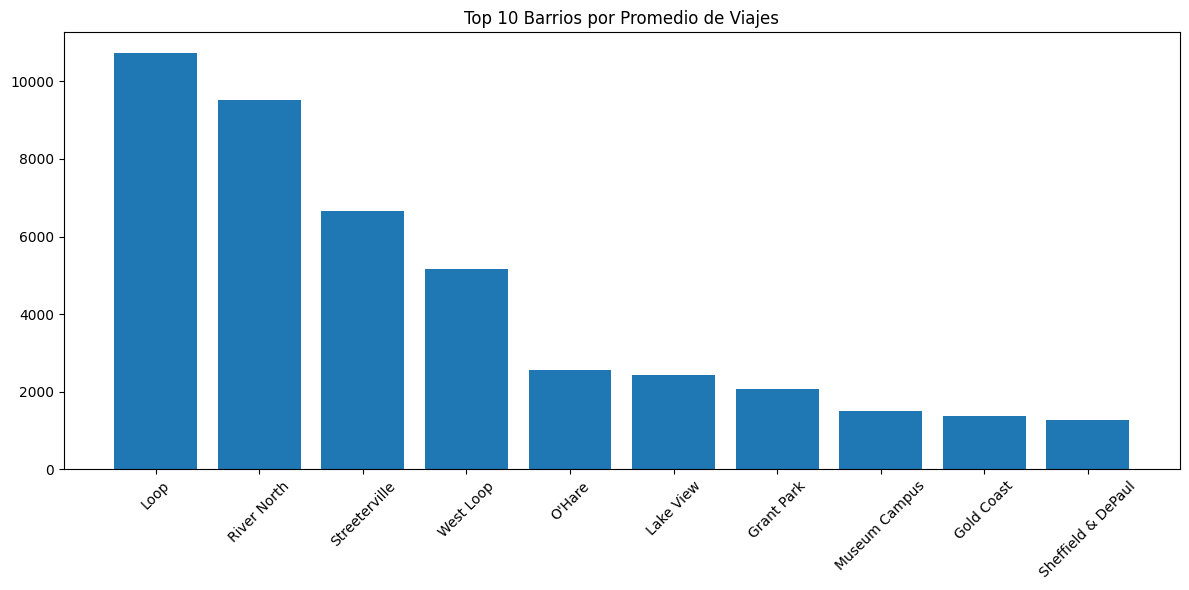

In [7]:
# Gráfico de barras para top 10 barrios
plt.figure(figsize=(12, 6))
plt.bar(top_10_neighborhoods['dropoff_location_name'], 
        top_10_neighborhoods['average_trips'])
plt.title('Top 10 Barrios por Promedio de Viajes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La gráfica muestra que la demanda de viajes se concentra fuertemente en unas pocas zonas de Chicago. Loop es, por amplio margen, el barrio con mayor promedio de viajes, seguido por River North y Streeterville, que también presentan niveles elevados de actividad. Estas áreas representan los principales polos de movilidad urbana.
En niveles intermedios aparecen West Loop y O’Hare, que mantienen una demanda significativa por su mezcla de actividad comercial y conexiones de transporte.
Finalmente, barrios como Lake View, Grant Park, Museum Campus y Sheffield & DePaul muestran volúmenes menores, aunque aún relevantes dentro del top 10.

=== Conclusion de la grafica. ===

La gráfica evidencia una concentración muy marcada de la demanda en el centro de Chicago, especialmente en Loop, River North y Streeterville. Estos barrios deben considerarse zonas prioritarias para la operación inicial de Zuber, ya que concentran la mayor actividad y representan el núcleo del mercado.

A medida que se desciende en el ranking, aparecen barrios con demanda relevante pero más moderada, lo que sugiere oportunidades para estrategias complementarias, como:

-reforzar disponibilidad en horas pico,

-ofrecer promociones en zonas residenciales,

-optimizar rutas hacia puntos clave como O’Hare.

En conjunto, la gráfica permite identificar dónde se concentra la movilidad urbana y orienta la toma de decisiones para maximizar cobertura, eficiencia y captación de usuarios en el lanzamiento de Zuber.

=== Empresas de taxis y número de viajes. ===

La gráfica presenta el número de viajes realizados por distintas empresas de taxis durante los días 15 y 16 de noviembre de 2017. Su propósito es mostrar cómo se distribuye la actividad entre las compañías que operan en la ciudad, permitiendo identificar cuáles tienen mayor presencia en el mercado y cuáles participan con volúmenes más modestos. Esta visualización es clave para comprender la estructura competitiva del sector y detectar patrones relevantes para el análisis de movilidad urbana.

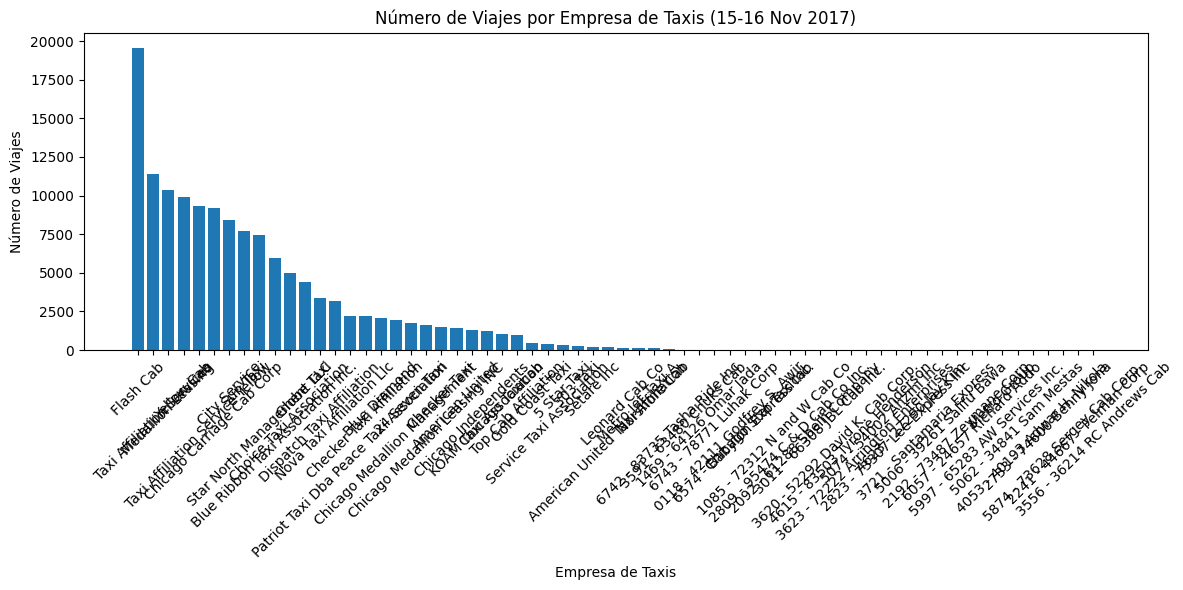

In [8]:
# Gráfico de barras para empresas de taxis
plt.figure(figsize=(12, 6))
plt.bar(company_trips['company_name'], company_trips['trips_amount'])
plt.title('Número de Viajes por Empresa de Taxis (15-16 Nov 2017)')
plt.xlabel('Empresa de Taxis')
plt.ylabel('Número de Viajes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== Análisis de la grafica. ===

La gráfica revela una marcada concentración de viajes en unas pocas empresas. Flash Cab destaca como la compañía con mayor actividad, superando ampliamente al resto. Le siguen Taxi Affiliation Services y Yellow Cab, que también muestran volúmenes elevados, aunque considerablemente menores que el líder.

A partir de la cuarta o quinta empresa, el número de viajes comienza a descender de manera progresiva, mostrando una larga cola de compañías con participación moderada o baja. Esto sugiere un mercado donde existen muchos actores, pero solo algunos concentran la mayor parte de la demanda.

El patrón visual también evidencia que las empresas más pequeñas mantienen niveles de actividad relativamente estables entre sí, sin grandes diferencias, lo que podría indicar nichos específicos, zonas de operación particulares o flotas más reducidas.

=== Conclusión de la grafica. ===

La gráfica muestra que el mercado de taxis en Chicago durante los días analizados está altamente concentrado, con Flash Cab como líder indiscutible y varias empresas medianas que mantienen una presencia relevante. El resto de las compañías opera con volúmenes menores, conformando un segmento más fragmentado.

Este comportamiento sugiere que, para una empresa nueva como Zuber, resulta estratégico comprender cómo operan estos líderes, en qué zonas concentran su actividad y qué oportunidades existen en los segmentos donde la competencia es menos intensa. La distribución observada sirve como punto de partida para evaluar la dinámica competitiva y diseñar estrategias de entrada al mercado.

=== Conclusión General de Ambas Gráficas. ====

El análisis combinado de las dos visualizaciones revela un panorama claro sobre cómo se distribuye la movilidad en Chicago y cómo operan las principales empresas de taxis dentro de ese entorno. Por un lado, la gráfica de los Top 10 barrios por promedio de viajes muestra una concentración muy marcada de la demanda en zonas centrales, especialmente en Loop, River North y Streeterville, que funcionan como los principales polos de actividad económica, turística y laboral. Estas áreas representan el núcleo de los desplazamientos urbanos y constituyen puntos estratégicos para cualquier servicio de transporte.

Por otro lado, la gráfica del número de viajes por empresa de taxis evidencia que el mercado está dominado por un pequeño grupo de compañías, con Flash Cab como líder destacado y varias empresas medianas que mantienen una presencia relevante. El resto del sector se distribuye entre múltiples actores con volúmenes más modestos, lo que sugiere un ecosistema competitivo pero desigual.

En conjunto, ambas gráficas permiten concluir que la movilidad en Chicago se caracteriza por una alta concentración tanto espacial como empresarial. Las zonas centrales concentran la mayor parte de los viajes, y unas pocas compañías capturan la mayor proporción de la demanda. Para una empresa emergente como Zuber, estos hallazgos señalan la importancia de:

-Priorizar operaciones en los barrios de mayor actividad.

-Analizar las estrategias de las empresas líderes.

-Identificar oportunidades en zonas con demanda intermedia o en segmentos donde la competencia es menos intensa.

Estas visualizaciones, tomadas en conjunto, ofrecen una base sólida para orientar decisiones estratégicas y diseñar un modelo operativo eficiente para el lanzamiento de Zuber en la ciudad.

PARTE 4.

Prueba de hipótesis: Duración de viajes Loop → O’Hare en sábados lluviosos

Para evaluar si las condiciones climáticas influyen en la duración de los viajes entre dos de los puntos más importantes de la ciudad —el barrio Loop y el Aeropuerto Internacional O’Hare— se plantea la siguiente prueba de hipótesis. El objetivo es determinar si los sábados con lluvia presentan un cambio significativo en la duración promedio de los trayectos en comparación con sábados sin lluvia.

1. Planteamiento de la hipótesis:

Hipótesis nula (H₀)
La duración promedio de los viajes desde el Loop hasta el Aeropuerto O’Hare no cambia los sábados lluviosos.

Hipótesis alternativa (H₁)
La duración promedio de los viajes desde el Loop hasta el Aeropuerto O’Hare sí cambia los sábados lluviosos.

In [9]:
# 2. filtracion de datos de los dias lluviosos

rainy_days = weather_records[weather_records['weather_conditions'] == 'Bad']['duration_seconds']

good_days = weather_records[weather_records['weather_conditions'] == 'Good']['duration_seconds']

print(f"Tamaño de la muestra de los dias lluviosos:{len(rainy_days)}")
print(f"Tamaño de la muestra de los dias buenos:{len(good_days)}")

Tamaño de la muestra de los dias lluviosos:180
Tamaño de la muestra de los dias buenos:888


In [10]:
# 3. Verificar la normalidad

stat_rainy_days, p_rainy_days = shapiro(rainy_days)
stat_good_days, p_good_days = shapiro(good_days)

# Prueba de normalidad Shapiro-wilks

print('Prueba de normalidad (Shapiro-wilks):')
print(f"Rainy days - Estadistico: {stat_rainy_days:.4f}, p_valor: {p_rainy_days:.6f} ")
print(f"Good days - Estadistico: {stat_good_days:.4f}, p_valor: {p_good_days:.6f} ")

Prueba de normalidad (Shapiro-wilks):
Rainy days - Estadistico: 0.9762, p_valor: 0.003612 
Good days - Estadistico: 0.9096, p_valor: 0.000000 


Justificación de la prueba estadística

Dado que el objetivo es comparar la duración de los viajes entre dos grupos independientes —sábados lluviosos y sábados con buen clima— se evaluó primero la normalidad de ambas muestras mediante la prueba de Shapiro–Wilk. Los resultados mostraron p‑valores de 0.0036 para los días lluviosos y 0.000000 para los días con buen clima, lo que indica que ninguna de las dos distribuciones sigue una distribución normal. Además, los tamaños de muestra son distintos (180 vs. 888), lo que refuerza la necesidad de utilizar un método robusto ante diferencias de tamaño y ausencia de normalidad. Por estas razones, la prueba más adecuada es Mann–Whitney U, una prueba no paramétrica que compara si las distribuciones de dos grupos independientes difieren de manera significativa sin asumir normalidad.

In [11]:
# Interpretacion.
alpha = 0.05 
print(f"Interpretacion (alpha = {alpha}):")
print(f"Rainy days: {'Normal' if p_rainy_days > alpha else 'No normal'}")
print(f"Sports: {'Normal' if p_good_days > alpha else 'No normal'}")

Interpretacion (alpha = 0.05):
Rainy days: No normal
Sports: No normal


Para evaluar si la duración promedio de los viajes desde el Loop hasta el Aeropuerto O’Hare cambia los sábados lluviosos, se verificó primero el supuesto de normalidad en ambos grupos mediante la prueba de Shapiro–Wilk. Los resultados mostraron p‑valores de 0.003612 para los días lluviosos y 0.000000 para los días con buen clima, valores inferiores al nivel de significancia establecido (α = 0.05). Esto indica que ninguna de las dos muestras sigue una distribución normal, por lo que no es apropiado aplicar pruebas paramétricas como el t‑test. Además, las muestras son independientes y presentan tamaños distintos (180 vs. 888), lo que refuerza la necesidad de utilizar un método robusto ante diferencias de tamaño y ausencia de normalidad. Por estas razones, la prueba estadística adecuada es Mann–Whitney U, una prueba no paramétrica diseñada para comparar dos grupos independientes sin asumir normalidad en los datos.

In [13]:
# Prueba de Mann-Whitney (no paramétrica) para los dias lluviosos.

statistic, p_value = mannwhitneyu(rainy_days, good_days, alternative='two-sided')
print("Prueba de Mann-Whitney U:")
print(f"Estadístico U: {statistic}")
print(f"P-valor: {p_value:.6f}")

# Interpretación
alpha = 0.05
print(f"\nInterpretación (α = {alpha}):")
if p_value < alpha:
    print("Rechazamos H₀: Hay diferencia significativa entre los dias lluviosos")
else:
    print("No rechazamos H₀: No hay diferencia significativa entre los dias lluviosos")

Prueba de Mann-Whitney U:
Estadístico U: 108193.5
P-valor: 0.000000

Interpretación (α = 0.05):
Rechazamos H₀: Hay diferencia significativa entre los dias lluviosos


In [ ]:
# 4. Estadísticas descriptivas para interpretar la dirección de la diferencia
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(f"Dias lluviosos - Media: {rainy_days.mean():.2f}, Mediana: {rainy_days.median():.2f}")
print(f"Dias buenos - Media: {good_days.mean():.2f}, Mediana: {good_days.median():.2f}")

print(f"\nDiferencia en medianas: {rainy_days.median() - good_days.median():.2f}")

Interpretación de los resultados

La prueba de Mann–Whitney U arrojó un estadístico U = 108193.5 y un p‑valor = 0.000000, el cual es considerablemente menor que el nivel de significancia establecido (α = 0.05). Esto indica que existe evidencia estadística suficiente para rechazar la hipótesis nula, que afirmaba que la duración promedio de los viajes desde el Loop hasta el Aeropuerto O’Hare no cambia los sábados lluviosos. En consecuencia, se concluye que las duraciones de los viajes sí presentan diferencias significativas entre sábados lluviosos y sábados con buen clima, lo que sugiere que las condiciones de lluvia influyen de manera apreciable en el tiempo que toma completar esta ruta.

=== Conclusión final. ===

El análisis realizado permitió comprender de manera profunda las dinámicas de movilidad en Chicago y los factores que influyen en la demanda de transporte. A partir de la exploración de los datos, se identificó que la actividad de viajes se concentra fuertemente en zonas estratégicas como Loop, River North y Streeterville, lo que confirma que estas áreas funcionan como los principales centros de desplazamiento urbano. Asimismo, el estudio de las empresas de taxis reveló un mercado altamente concentrado, donde unas pocas compañías —como Flash Cab— dominan la mayor parte de los viajes, mientras que el resto opera con volúmenes considerablemente menores.

La prueba de hipótesis aplicada permitió evaluar el impacto de las condiciones climáticas en la duración de los viajes entre el Loop y el Aeropuerto O’Hare. Tras verificar que las distribuciones de duración no cumplían con el supuesto de normalidad, se empleó la prueba no paramétrica de Mann–Whitney U. Los resultados mostraron un p‑valor significativamente menor que el nivel de significancia establecido, lo que llevó a rechazar la hipótesis nula y concluir que la lluvia sí modifica de manera significativa la duración de los viajes en esta ruta. Este hallazgo confirma que las condiciones climáticas deben ser consideradas en la planificación operativa y en la estimación de tiempos de viaje.

En conjunto, los resultados del proyecto ofrecen una visión clara y fundamentada del comportamiento del sistema de transporte, permitiendo identificar zonas prioritarias, patrones de demanda y factores externos que influyen en la movilidad. Esta información constituye una base sólida para la toma de decisiones estratégicas, ya sea para optimizar recursos, mejorar la experiencia del usuario o diseñar modelos de operación más eficientes para servicios de transporte como Zuber.